# Analysis of the JEPA_10k

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

Import of the latents

In [2]:
PATH = "C:\\Users\\alexa\\OneDrive\\Bureau\\JEPA_4_PLM\\latents\\10k_SIGReg\\cont_targ_lat_10k.pt"
list_results = torch.load(PATH, map_location=torch.device('cpu'))
print(list_results)
print(list_results[0]["context_latent"].shape)
print("length of list_results: ", len(list_results))

[{'prot_name': 'UniRef50_B9TJK4', 'context_latent': tensor([[[ 0.5228, -0.0334,  0.1471,  ...,  0.7364, -0.7692, -0.7122],
         [ 0.4855,  0.0977,  0.2478,  ...,  0.5409, -0.5032, -0.2810],
         [ 0.3571, -0.0176,  0.2461,  ...,  0.5945, -0.5246, -0.5369],
         ...,
         [ 1.3148,  0.5961, -0.1022,  ..., -1.0567, -0.5563,  1.4727],
         [ 2.1573,  0.6766,  0.7148,  ...,  0.2978, -0.6195,  0.2652],
         [ 2.2796,  0.9689,  0.5478,  ...,  0.8337, -0.3539, -0.2964]]]), 'target_latent': tensor([[[-0.1542,  0.1139, -0.7630,  ...,  2.0956, -0.3783, -0.4593],
         [ 0.1587, -0.1623, -0.4264,  ...,  1.0438, -0.3195, -0.5589],
         [-0.0705, -0.1096, -0.6436,  ...,  0.8210, -0.2442, -0.2547],
         ...,
         [ 0.2305, -0.1819,  0.1569,  ..., -4.7946, -0.1761, -0.5446],
         [ 0.0808,  0.2440, -0.6731,  ..., -8.9263,  0.2997,  0.2175],
         [ 0.5583,  0.1486, -1.3695,  ..., -4.9900,  0.1903,  0.2498]]]), 'full_seq': 'GVIAATTGELSMNINGQLSNHNSLVAQGNMAL

In [3]:
print(list_results[0]["context_latent"].shape)

# Remove the batch dimension for the whole list of results
for i in range(len(list_results)):
    list_results[i]["context_latent"] = list_results[i]["context_latent"].squeeze(0)
    list_results[i]["target_latent"] = list_results[i]["target_latent"].squeeze(0)

print(list_results[0]["context_latent"].shape)

torch.Size([1, 348, 320])
torch.Size([348, 320])


Analysis ideas:
- Compare the context and target latents using cosine similarity or Euclidean distance.
- Visualize the latent space using dimensionality reduction techniques like PCA or t-SNE.

## Cosine similarity between context and target latents

Check average cosine similarity

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
average_cosim = 0
for i in range(len(list_results)):
    context_latents = list_results[i]["context_latent"].cpu().numpy()
    target_latents = list_results[i]["target_latent"].cpu().numpy()
    cos_sim = cosine_similarity(context_latents, target_latents)
    euclidean_dist = torch.cdist(list_results[i]["context_latent"], list_results[i]["target_latent"], p=2)
    average_cos_sim = cos_sim.mean()
    average_euclidean_dist = euclidean_dist.mean()
    print(f"Average cosine similarity for {list_results[i]['prot_name']}: {average_cos_sim}")
    # print(f"Average Euclidean distance for {list_results[i]['prot_name']}: {average_euclidean_dist}")
    # print(f"Cosine similarity for {list_results[i]['prot_name']}: {cos_sim}")
    average_cosim += average_cos_sim
average_cosim /= len(list_results)
print(f"Average cosine similarity across all proteins: {average_cosim}")

Average cosine similarity for UniRef50_B9TJK4: -0.0004599779495038092
Average cosine similarity for UniRef50_P12264: -0.0011201869929209352
Average cosine similarity for UniRef50_A0A1M5DL89: 0.00026973968488164246
Average cosine similarity for UniRef50_A0A396HAN0: 0.0005170813528820872
Average cosine similarity for UniRef50_I2NE94: 0.0008727739914320409
Average cosine similarity for UniRef50_A0A817SU47: 4.8832447646418586e-05
Average cosine similarity for UniRef50_A0A1V4J234: 0.00040338397957384586
Average cosine similarity for UniRef50_A0A0G3GTD6: 0.0005071626510471106
Average cosine similarity for UniRef50_A0A221KA17: 3.522530460031703e-05
Average cosine similarity for UniRef50_A0A8H7ZNU4: 0.00024259033671114594
Average cosine similarity for UniRef50_A0A510P8F1: 0.000330055074300617
Average cosine similarity for UniRef50_A0A945S0Q6: 0.0003614334564190358
Average cosine similarity for UniRef50_A0A7D5TPV6: 0.0005761093343608081
Average cosine similarity for UniRef50_Q755Z0: 0.000254912

Check variance by dim

In [6]:
# Variance by dimension
for i in range(len(list_results)):
    context_latents = list_results[i]["context_latent"].cpu().numpy()
    target_latents = list_results[i]["target_latent"].cpu().numpy()
    context_variance = context_latents.var(axis=0)
    target_variance = target_latents.var(axis=0)
    dead_dims = (target_variance < 1e-1).sum()
    print("Number of dead dimensions for {}: {}".format(list_results[i]['prot_name'], dead_dims))

Number of dead dimensions for UniRef50_B9TJK4: 99
Number of dead dimensions for UniRef50_P12264: 120
Number of dead dimensions for UniRef50_A0A1M5DL89: 43
Number of dead dimensions for UniRef50_A0A396HAN0: 36
Number of dead dimensions for UniRef50_I2NE94: 41
Number of dead dimensions for UniRef50_A0A817SU47: 42
Number of dead dimensions for UniRef50_A0A1V4J234: 47
Number of dead dimensions for UniRef50_A0A0G3GTD6: 42
Number of dead dimensions for UniRef50_A0A221KA17: 36
Number of dead dimensions for UniRef50_A0A8H7ZNU4: 33
Number of dead dimensions for UniRef50_A0A510P8F1: 30
Number of dead dimensions for UniRef50_A0A945S0Q6: 34
Number of dead dimensions for UniRef50_A0A7D5TPV6: 40
Number of dead dimensions for UniRef50_Q755Z0: 45
Number of dead dimensions for UniRef50_A0A6P6YJ02: 36
Number of dead dimensions for UniRef50_A0A0V1JXA2: 61
Number of dead dimensions for UniRef50_A0A3M1H0C2: 34
Number of dead dimensions for UniRef50_A0A183VNG8: 33
Number of dead dimensions for UniRef50_A0A8

PCA de tous les vecteurs moyen d'AA des 200 protéines

In [7]:
list_results[0]["context_latent"]


tensor([[ 0.5228, -0.0334,  0.1471,  ...,  0.7364, -0.7692, -0.7122],
        [ 0.4855,  0.0977,  0.2478,  ...,  0.5409, -0.5032, -0.2810],
        [ 0.3571, -0.0176,  0.2461,  ...,  0.5945, -0.5246, -0.5369],
        ...,
        [ 1.3148,  0.5961, -0.1022,  ..., -1.0567, -0.5563,  1.4727],
        [ 2.1573,  0.6766,  0.7148,  ...,  0.2978, -0.6195,  0.2652],
        [ 2.2796,  0.9689,  0.5478,  ...,  0.8337, -0.3539, -0.2964]])

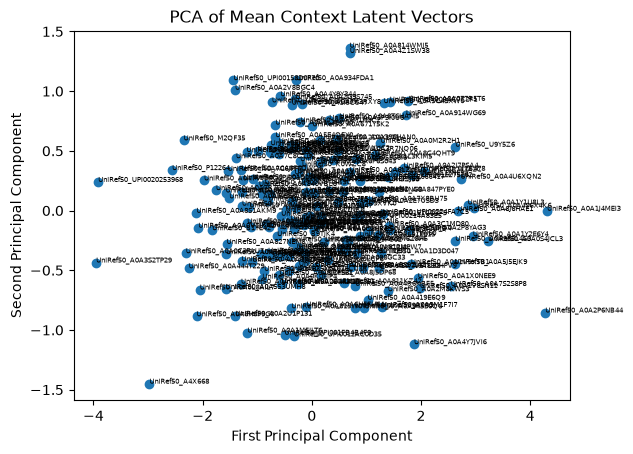

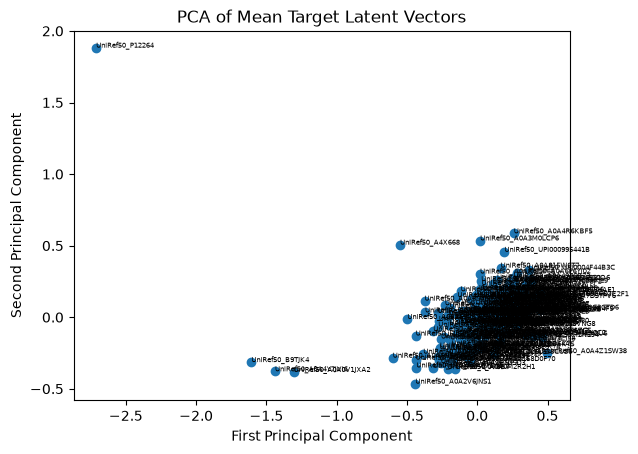

In [11]:
import numpy as np
from sklearn.decomposition import PCA
list_results[0]["context_latent"]
# Obtaining the list of the mean prot latent vectors for each protein
for i in range(len(list_results)):
    list_results[i]["mean_context_latent"] = list_results[i]["context_latent"].mean(axis=0)
    list_results[i]["mean_target_latent"] = list_results[i]["target_latent"].mean(axis=0)

# Creating a DataFrame with the mean latent vectors for each protein
mean_context_latents = np.array([result["mean_context_latent"] for result in list_results])
mean_target_latents = np.array([result["mean_target_latent"] for result in list_results])

# Doing a PCA and displaying it using matplotlib, every prot_name is printed on the plot
pca_context = PCA(n_components=2)
transformed_context = pca_context.fit_transform(mean_context_latents)
import matplotlib.pyplot as plt
plt.scatter(transformed_context[:, 0], transformed_context[:, 1])
for i, prot_name in enumerate([result["prot_name"] for result in list_results]):
    plt.annotate(prot_name, (transformed_context[i, 0], transformed_context[i, 1]), fontsize=5)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Mean Context Latent Vectors")
plt.show()


# PCA but on the mean target latent vectors
pca_target = PCA(n_components=2)
transformed_target = pca_target.fit_transform(mean_target_latents)
plt.scatter(transformed_target[:, 0], transformed_target[:, 1])
for i, prot_name in enumerate([result["prot_name"] for result in list_results]):
    plt.annotate(prot_name, (transformed_target[i, 0], transformed_target[i, 1]), fontsize=5)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Mean Target Latent Vectors")
plt.show()

Without the top right prot

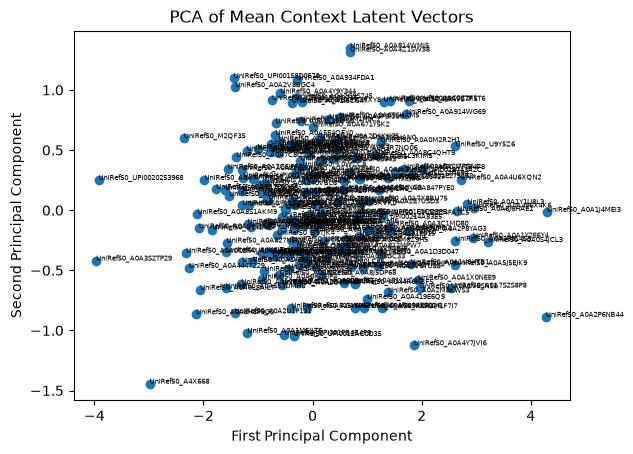

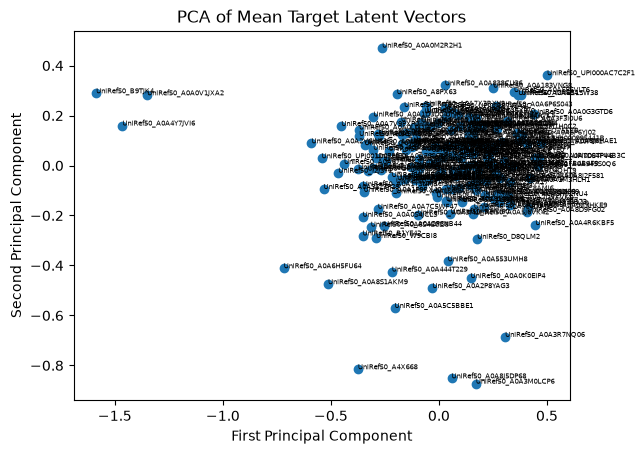

In [15]:
# delete the prot "UniRef50_P12264" from the list_results
list_results = [result for result in list_results if result["prot_name"] != "UniRef50_P12264"]

import numpy as np
from sklearn.decomposition import PCA
list_results[0]["context_latent"]
# Obtaining the list of the mean prot latent vectors for each protein
for i in range(len(list_results)):
    list_results[i]["mean_context_latent"] = list_results[i]["context_latent"].mean(axis=0)
    list_results[i]["mean_target_latent"] = list_results[i]["target_latent"].mean(axis=0)

# Creating a DataFrame with the mean latent vectors for each protein
mean_context_latents = np.array([result["mean_context_latent"] for result in list_results])
mean_target_latents = np.array([result["mean_target_latent"] for result in list_results])

# Doing a PCA and displaying it using matplotlib, every prot_name is printed on the plot
pca_context = PCA(n_components=2)
transformed_context = pca_context.fit_transform(mean_context_latents)
import matplotlib.pyplot as plt
plt.scatter(transformed_context[:, 0], transformed_context[:, 1])
for i, prot_name in enumerate([result["prot_name"] for result in list_results]):
    plt.annotate(prot_name, (transformed_context[i, 0], transformed_context[i, 1]), fontsize=5)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Mean Context Latent Vectors")
plt.show()


# PCA but on the mean target latent vectors
pca_target = PCA(n_components=2)
transformed_target = pca_target.fit_transform(mean_target_latents)
plt.scatter(transformed_target[:, 0], transformed_target[:, 1])
for i, prot_name in enumerate([result["prot_name"] for result in list_results]):
    plt.annotate(prot_name, (transformed_target[i, 0], transformed_target[i, 1]), fontsize=5)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Mean Target Latent Vectors")
plt.show()

Computing t-SNE on context latents...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 200 samples in 0.000s...
[t-SNE] Computed neighbors for 200 samples in 3.812s...
[t-SNE] Computed conditional probabilities for sample 200 / 200
[t-SNE] Mean sigma: 0.572748
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.815601
[t-SNE] KL divergence after 1000 iterations: 0.506140
Computing t-SNE on target latents...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 200 samples in 0.000s...
[t-SNE] Computed neighbors for 200 samples in 0.015s...
[t-SNE] Computed conditional probabilities for sample 200 / 200
[t-SNE] Mean sigma: 0.202898
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.970154
[t-SNE] KL divergence after 1000 iterations: 0.839333


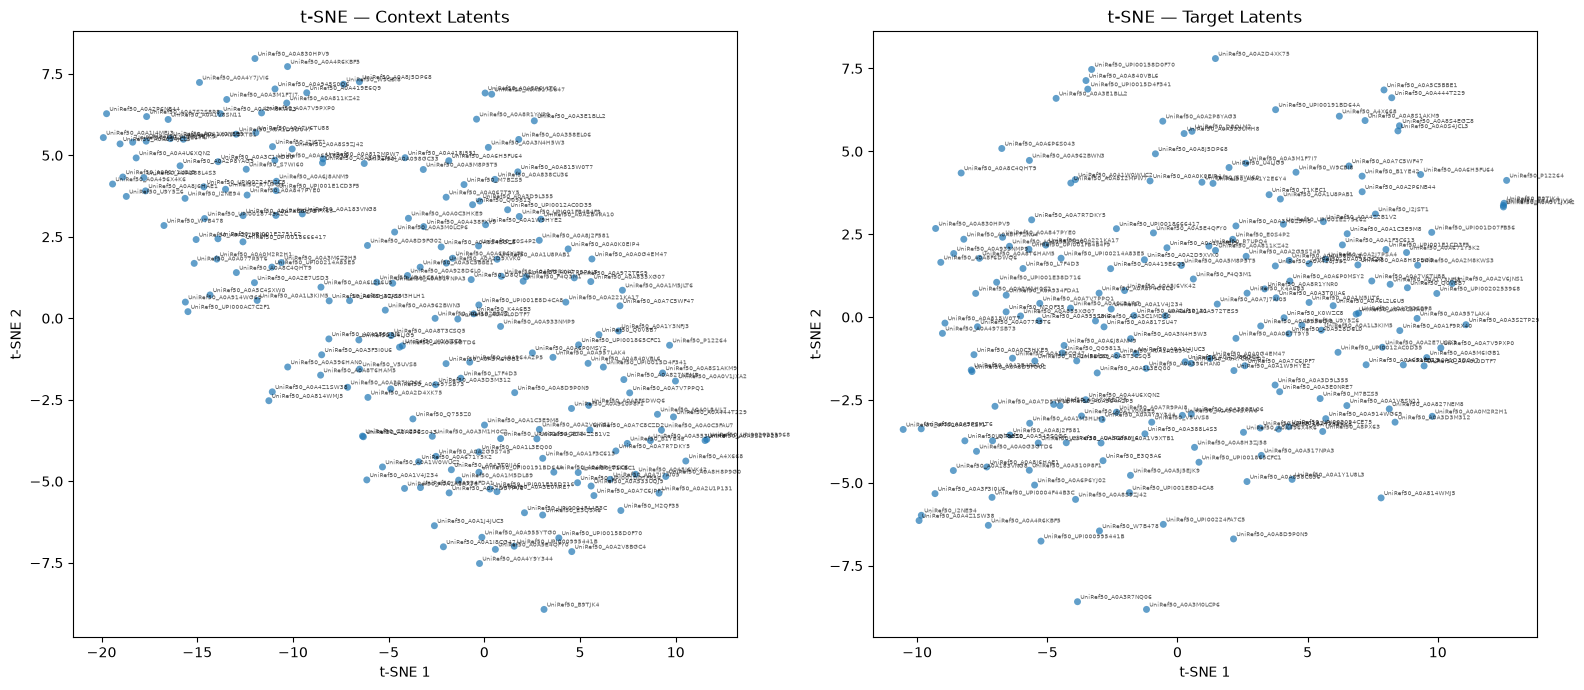

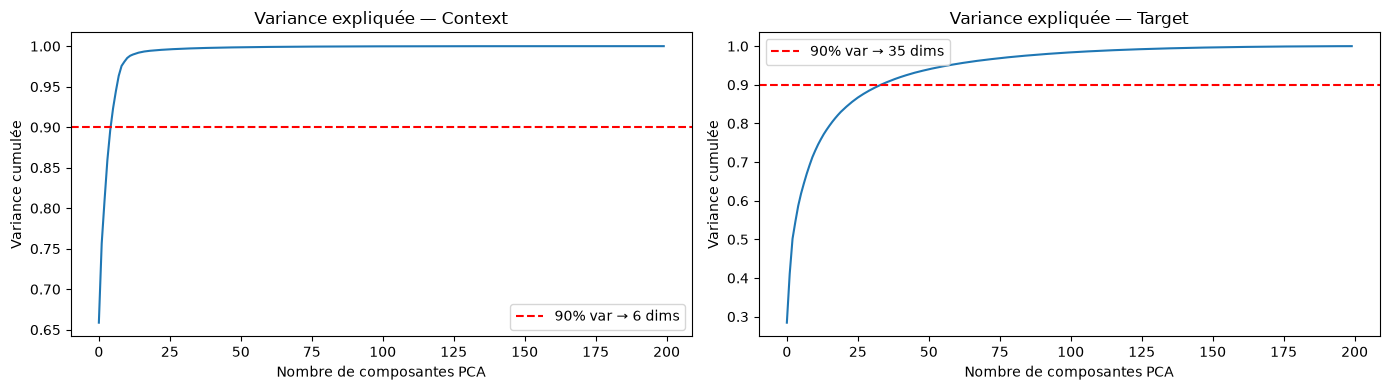

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ── Paramètres ──────────────────────────────────────────────────────────────
prot_names = [result["prot_name"] for result in list_results]
PERPLEXITY   = min(30, len(list_results) - 1)  # doit être < n_samples
N_ITER       = 1000
RANDOM_STATE = 42

# ── Réduction dimensionnelle préalable (recommandé avant t-SNE en haute dim) ─
# On réduit à 50 dims avec PCA avant t-SNE pour stabiliser et accélérer
n_pca_components = min(50, mean_context_latents.shape[1], len(list_results) - 1)

pca_pre = PCA(n_components=n_pca_components, random_state=RANDOM_STATE)
context_pca_pre = pca_pre.fit_transform(mean_context_latents)
target_pca_pre  = pca_pre.fit_transform(mean_target_latents)

# ── t-SNE ────────────────────────────────────────────────────────────────────
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    max_iter=N_ITER,
    learning_rate="auto",
    init="pca",          # init PCA = plus stable que random
    random_state=RANDOM_STATE,
    verbose=1,
)

print("Computing t-SNE on context latents...")
tsne_context = tsne.fit_transform(context_pca_pre)

print("Computing t-SNE on target latents...")
tsne_target  = tsne.fit_transform(target_pca_pre)

# ── Visualisation ─────────────────────────────────────────────────────────────
def plot_tsne(coords, names, title, ax):
    ax.scatter(coords[:, 0], coords[:, 1], s=25, alpha=0.7, edgecolors="none")
    for i, name in enumerate(names):
        ax.annotate(name, (coords[i, 0], coords[i, 1]),
                    fontsize=4, alpha=0.6,
                    xytext=(2, 2), textcoords="offset points")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_tsne(tsne_context, prot_names, "t-SNE — Context Latents", axes[0])
plot_tsne(tsne_target,  prot_names, "t-SNE — Target Latents",  axes[1])
plt.tight_layout()
plt.savefig("tsne_latents.png", dpi=150)
plt.show()

# ── Bonus : variance expliquée par la PCA (diagnostic du collapse) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, latents, label in [
    (axes[0], mean_context_latents, "Context"),
    (axes[1], mean_target_latents,  "Target"),
]:
    pca_diag = PCA().fit(latents)
    cumvar = np.cumsum(pca_diag.explained_variance_ratio_)
    n_dims_90 = np.searchsorted(cumvar, 0.90) + 1
    ax.plot(cumvar)
    ax.axhline(0.90, color="red", linestyle="--", label=f"90% var → {n_dims_90} dims")
    ax.set_xlabel("Nombre de composantes PCA")
    ax.set_ylabel("Variance cumulée")
    ax.set_title(f"Variance expliquée — {label}")
    ax.legend()
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

Distribution of cosine similarity intra-prot

In [9]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def extract_and_pool(latent_tensor):
    """
    Convertit le tenseur en array numpy et s'assure qu'il est au format 1D.
    Si vos latents contiennent une dimension 'séquence' (ex: Longueur x Dimension),
    on applique un mean-pooling pour obtenir un seul vecteur par protéine.
    """
    arr = latent_tensor.cpu().numpy()
    if arr.ndim == 2 and arr.shape[0] > 1 and arr.shape[1] > 1:
        arr = arr.mean(axis=0)  # Mean-pooling sur la longueur de la protéine
    return arr.flatten()

# --- 1. Préparation des données (Vectorisation) ---
context_embeddings = []
target_embeddings = []
prot_names = []

for res in list_results:
    context_embeddings.append(extract_and_pool(res["context_latent"]))
    target_embeddings.append(extract_and_pool(res["target_latent"]))
    prot_names.append(res.get("prot_name", "Unknown"))

# Création des matrices globales (N_proteines, D_dimensions)
X_context = np.array(context_embeddings)
X_target = np.array(target_embeddings)

print(f"📊 Données chargées : {X_context.shape[0]} protéines | Dimension latente : {X_context.shape[1]}")
print("-" * 60)


# --- 2. Analyse de l'Effondrement Global (Informationnel) ---
# On calcule la matrice de similarité cosinus de toutes les paires de contextes
cos_sim_matrix = cosine_similarity(X_context)

# On masque la diagonale (car la similarité d'une protéine avec elle-même est de 1)
n_samples = cos_sim_matrix.shape[0]
mask_hors_diag = ~np.eye(n_samples, dtype=bool)
paires_sim = cos_sim_matrix[mask_hors_diag]

avg_sim_inter = paires_sim.mean()
std_sim_inter = paires_sim.std()

print("🔍 1. EFFONDREMENT GLOBAL (INFORMATIONNEL)")
print(f"➡️ Similarité cosinus moyenne inter-protéines : {avg_sim_inter:.4f}")
print(f"➡️ Écart-type de la similarité inter-protéines  : {std_sim_inter:.4f}")

if avg_sim_inter > 0.85:
    print("❌ ALERTE : Effondrement global détecté ! Le modèle projette presque toutes les protéines sur le même vecteur.")
elif std_sim_inter < 0.05:
    print("⚠️ ATTENTION : Faible diversité. Les représentations sont trop proches les unes des autres.")
else:
    print("✅ Statut : Bon. Le modèle discrimine correctement les différentes protéines.")
print("-" * 60)


# --- 3. Analyse de l'Effondrement Structurel (Dimensionnel) ---
# Analyse de la variance par dimension
variances = np.var(X_context, axis=0)
dead_dims = np.sum(variances < 1e-4)

# Analyse de la dimensionnalité effective via SVD (Singular Value Decomposition)
X_centered = X_context - X_context.mean(axis=0)
_, s, _ = np.linalg.svd(X_centered, full_matrices=False)
s_norm = s / s.sum()
cum_variance = np.cumsum(s_norm)
# Trouver combien de dimensions portent 95% de l'information
effective_dim_95 = np.argmax(cum_variance >= 0.95) + 1

print("📐 2. EFFONDREMENT STRUCTUREL (DIMENSIONNEL)")
print(f"➡️ Dimensions 'mortes' (Variance ~ 0) : {dead_dims} / {X_context.shape[1]}")
print(f"➡️ Dimensions effectives requises pour 95% de la variance : {effective_dim_95} / {min(X_context.shape)}")

if effective_dim_95 < 5:
    print("❌ ALERTE : Effondrement dimensionnel sévère ! Le modèle utilise un sous-espace minuscule.")
else:
    print("✅ Statut : Bon. L'espace latent exploite bien sa géométrie sans se contracter sur une seule ligne/plan.")
print("-" * 60)


# --- 4. Analyse de l'Alignement (Contexte vs Target) ---
# Dans un JEPA, le contexte doit être proche de sa propre cible (target)
# On calcule la similarité cosinus croisée
cross_sim = cosine_similarity(X_context, X_target)
# La diagonale représente l'alignement d'une même protéine
intra_sim = np.diag(cross_sim)

print("🔗 3. ALIGNEMENT CONTEXTE / TARGET")
print(f"➡️ Similarité moyenne Contexte ↔ Target (Même protéine) : {intra_sim.mean():.4f}")

if intra_sim.mean() < 0.4:
    print("⚠️ ATTENTION : Le contexte et la target ne s'alignent pas bien. La tâche prédictive n'est pas apprise.")
else:
    print("✅ Statut : Bon. Le bloc contexte sait prédire les propriétés de la target.")
print("-" * 60)

📊 Données chargées : 200 protéines | Dimension latente : 320
------------------------------------------------------------
🔍 1. EFFONDREMENT GLOBAL (INFORMATIONNEL)
➡️ Similarité cosinus moyenne inter-protéines : 0.6183
➡️ Écart-type de la similarité inter-protéines  : 0.2849
✅ Statut : Bon. Le modèle discrimine correctement les différentes protéines.
------------------------------------------------------------
📐 2. EFFONDREMENT STRUCTUREL (DIMENSIONNEL)
➡️ Dimensions 'mortes' (Variance ~ 0) : 0 / 320
➡️ Dimensions effectives requises pour 95% de la variance : 87 / 200
✅ Statut : Bon. L'espace latent exploite bien sa géométrie sans se contracter sur une seule ligne/plan.
------------------------------------------------------------
🔗 3. ALIGNEMENT CONTEXTE / TARGET
➡️ Similarité moyenne Contexte ↔ Target (Même protéine) : 0.0482
⚠️ ATTENTION : Le contexte et la target ne s'alignent pas bien. La tâche prédictive n'est pas apprise.
----------------------------------------------------------

In [8]:
X_context.shape, X_target.shape

((200, 320), (200, 320))

In [9]:
protA_context = X_context[0]
print(protA_context.shape)
protA_target = X_target[0]
print(protA_target.shape)

(320,)
(320,)


In [11]:
print(cosine_similarity(protA_context.reshape(1, -1), protA_target.reshape(1, -1)))

[[-0.02158371]]


In [12]:
prot = list_results[0]
print(len(prot["context_latent"]), len(prot["target_latent"]))

348 348


In [53]:
prot = list_results[0]
print(prot["prot_name"])
print(f"len context_latent: {len(prot['context_latent'][347])}")
print(f"len target_latent: {len(prot['target_latent'])}")
print(f"full_seq: {prot['full_seq']}")
print(f"masked_seq: {prot['masked_seq']}")
dico_AA = {}


UniRef50_B9TJK4
len context_latent: 320
len target_latent: 348
full_seq: GVIAATTGELSMNINGQLSNHNSLVAQGNMALKSSSLQNTGEVLSGADMHIDTGDLNNQNKIIAATSLTVNANHISNANALLAAGQDMNMTANQLSGDGRVIAGGNLTANLQQDYLQTTGLMQADGDLSLSSLGAIVNQTSILAGNTLLIQADRLNNSGELSGADTELTIIDTLMNTGLIDGSNTFIQADTLTNQGTGQIFGDHVAIQARRLNNLAQTVNGVSDAATIAARERLELGVSEALVNQSGSMIFSLGELSIGRELDAQHGATGQGDSLVNSDATIEADGNMQLNMASIQNLNAGVTTESVETGTVSYDQFTPRGQGGLYNSQDYPLWQIGNENISWRYG
masked_seq: GVIAATTGELSMN<mask>NGQLSNHNSLVAQGNM<mask><mask>K<mask>SS<mask><mask><mask>TG<mask>VLSGADMHIDTGDLNNQNKIIAATSL<mask>V<mask>ANH<mask>SNANALLA<mask>G<mask>DMNMTANQLSGD<mask>R<mask>IA<mask>GN<mask>TANLQQ<mask>YLQTTGLMQAD<mask>D<mask>SLSSL<mask><mask>IVN<mask>T<mask>I<mask>AGNTLLIQADRLNNSGELSGADTELTII<mask>TLMNTGLIDGSNTFI<mask>ADTLTNQGTGQIFG<mask>H<mask><mask>IQARRLNN<mask>AQTVNGVSDAATIAAR<mask>RLELGVSEALVNQS<mask>S<mask>IFSLGE<mask>S<mask>GRELDAQHGAT<mask>QGDSLVNSDAT<mask><mask>A<mask><mask>NMQL<mask>MASIQNLNAG<mask>TT<mask>SVETG<mask>VSYDQFTP<mask>GQGG<mask><mask>NS

In [ ]:
prot = list_results[0]
print(f"len masked_seq: {len(prot['masked_seq'])}, len full_seq: {len(prot['full_seq'])}")
for i in range (340, 346):
    print(f"index: {i}, AA: {prot['full_seq'][i]}, Latent shape: {prot['context_latent'][i].shape}")


In [98]:
# Affichage de la reduction de dimension de chaque vecteur moyen d'un type d'Acide Aminée pour ProtA et ProtB

i = 0
g = 0
wait = False
full_seq_dico = {}

print(len(prot["masked_seq"]))
# pour toutes les prot:
prot_id = 0
for prot in list_results:
    prot_id += 1
    print(f"Processing protein {prot_id}: {prot['prot_name']}")
    i = 0
    g = 0
    wait = False
    while i < len(prot["masked_seq"])-1:
        if i == len(prot["full_seq"]):
            break
        g = i
        if prot["masked_seq"][i] == "<":
            wait = True
        if prot["masked_seq"][i] == ">":
            wait = False
            g = i
        # print(f"i={i}, g={g}, AA: {prot['full_seq'][g]}, Latent shape: {prot['context_latent'][g].shape}")
        if prot["full_seq"][g] not in full_seq_dico:
            full_seq_dico[prot["full_seq"][g]] = [prot['context_latent'][g]]
        else:
            full_seq_dico[prot["full_seq"][g]].append(prot['context_latent'][g])

        i+=1

1355
Processing protein 1: UniRef50_B9TJK4
Processing protein 2: UniRef50_P12264
Processing protein 3: UniRef50_A0A1M5DL89
Processing protein 4: UniRef50_A0A396HAN0
Processing protein 5: UniRef50_I2NE94
Processing protein 6: UniRef50_A0A817SU47
Processing protein 7: UniRef50_A0A1V4J234
Processing protein 8: UniRef50_A0A0G3GTD6
Processing protein 9: UniRef50_A0A221KA17
Processing protein 10: UniRef50_A0A8H7ZNU4
Processing protein 11: UniRef50_A0A510P8F1
Processing protein 12: UniRef50_A0A945S0Q6
Processing protein 13: UniRef50_A0A7D5TPV6
Processing protein 14: UniRef50_Q755Z0
Processing protein 15: UniRef50_A0A6P6YJ02
Processing protein 16: UniRef50_A0A0V1JXA2
Processing protein 17: UniRef50_A0A3M1H0C2
Processing protein 18: UniRef50_A0A183VNG8
Processing protein 19: UniRef50_A0A8J6HAE1
Processing protein 20: UniRef50_A0A7J7AI05
Processing protein 21: UniRef50_A0A2B4RA10
Processing protein 22: UniRef50_Q09813
Processing protein 23: UniRef50_A0A419E6Q9
Processing protein 24: UniRef50_A0A

320


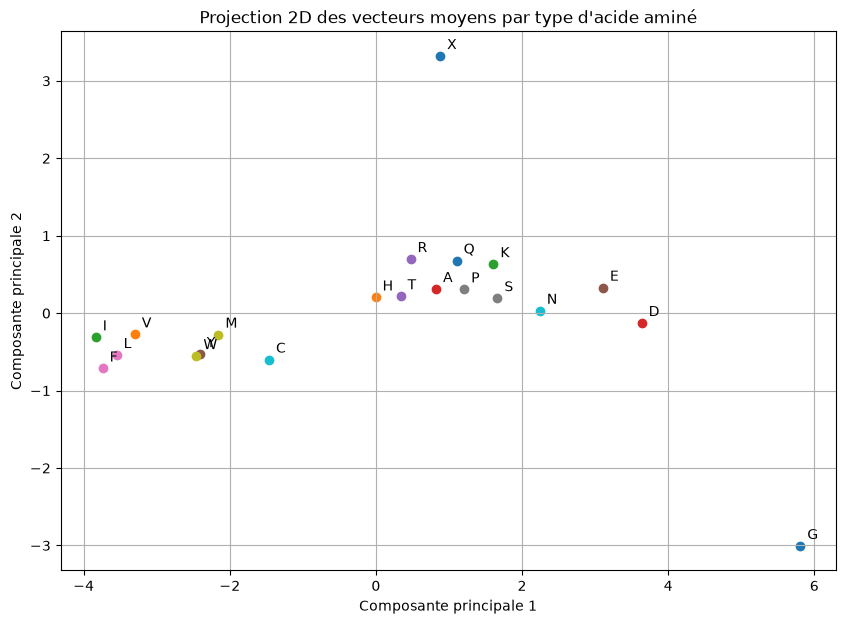

In [99]:
# mean vector for each amino acid type
mean_vectors = {}
for aa, latents in full_seq_dico.items():
    stacked_latents = torch.stack(latents)
    mean_vector = stacked_latents.mean(dim=0)
    mean_vectors[aa] = mean_vector
print(len(mean_vectors["A"]))

# project 2D d chaque vecteur dans un meme plot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. Préparer les données sous forme de matrice (n_samples, 320)
labels = list(mean_vectors.keys())
data_matrix = np.stack([mean_vectors[aa].numpy() for aa in labels])

# 2. Appliquer la PCA sur TOUTE la matrice
pca = PCA(n_components=2)
projected_data = pca.fit_transform(data_matrix)

# ... (après avoir calculé projected_data comme dans le code précédent)

plt.figure(figsize=(10, 7))

for i, aa in enumerate(labels):
    x, y = projected_data[i, 0], projected_data[i, 1]
    
    # Tracer le point
    plt.scatter(x, y)
    
    # Ajouter le texte à côté du point
    # xytext=(5, 5) permet de décaler le texte légèrement pour ne pas masquer le point
    plt.annotate(aa, (x, y), xytext=(5, 5), textcoords='offset points')

plt.title("Projection 2D des vecteurs moyens par type d'acide aminé")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.show()

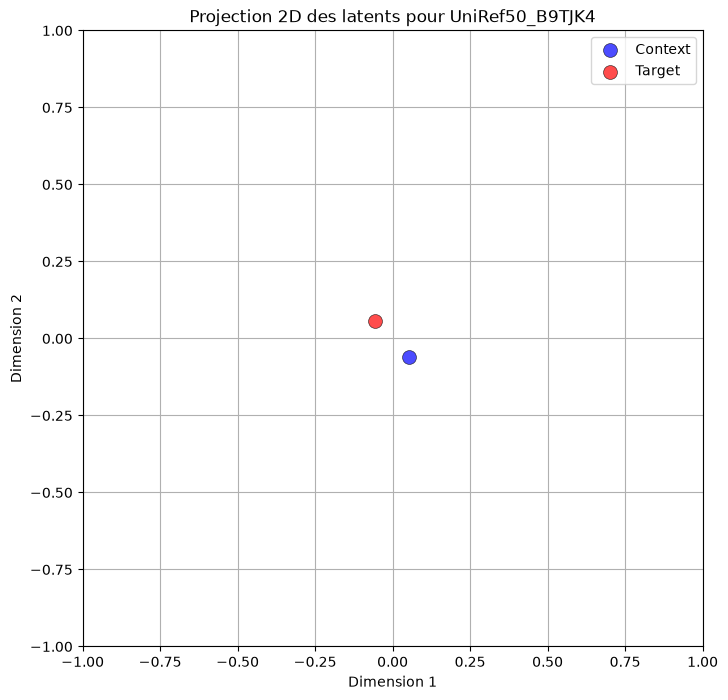

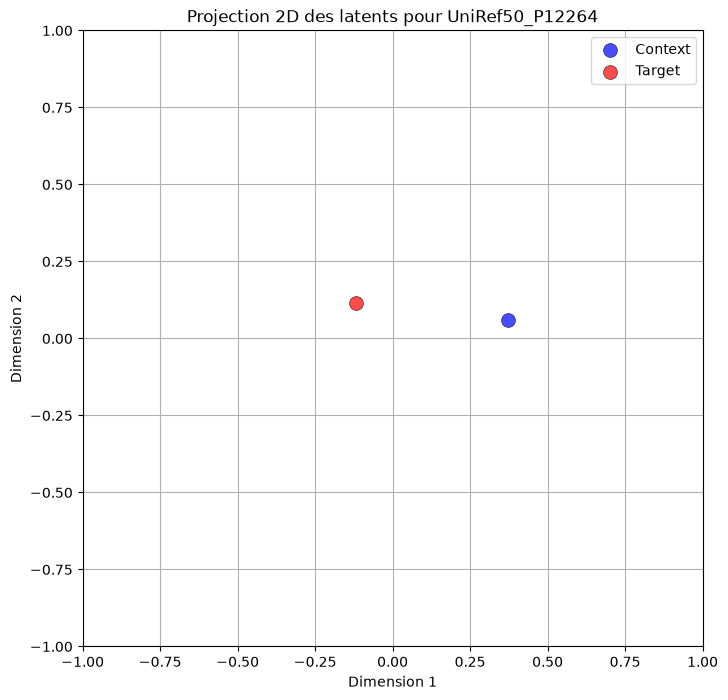

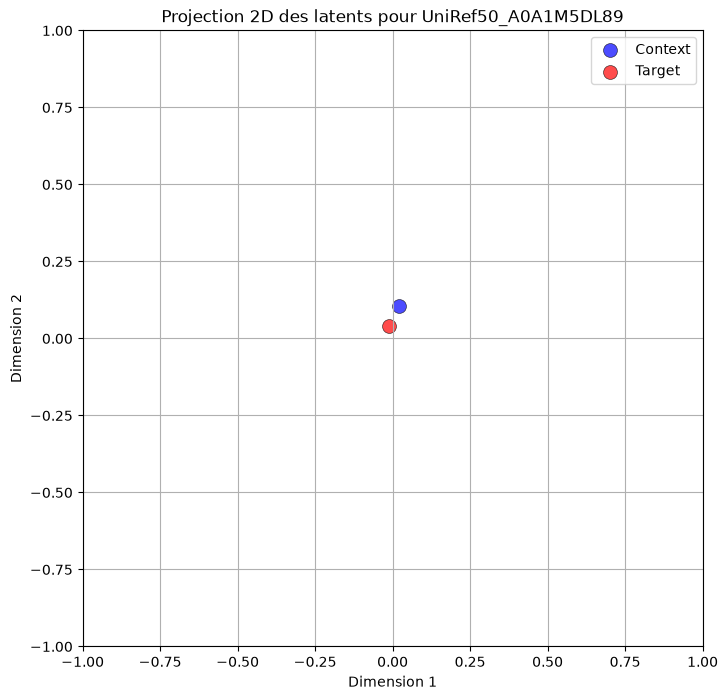

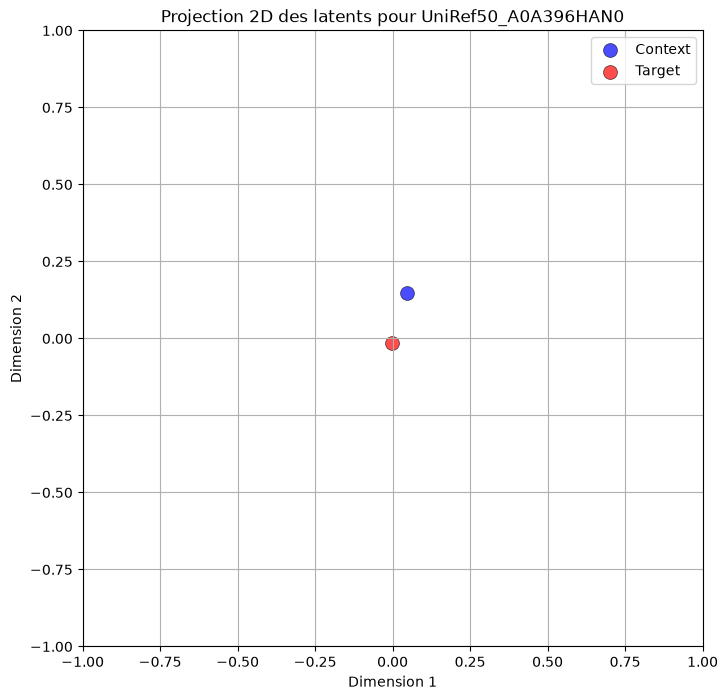

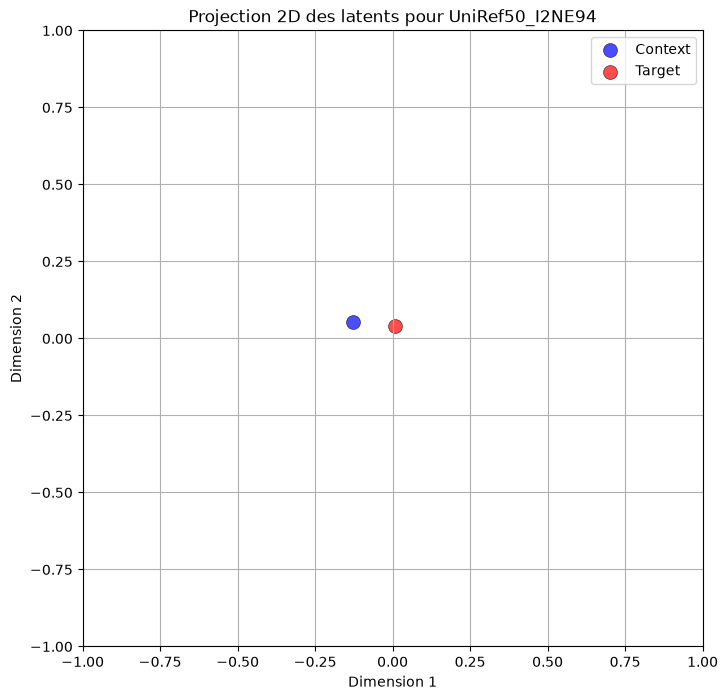

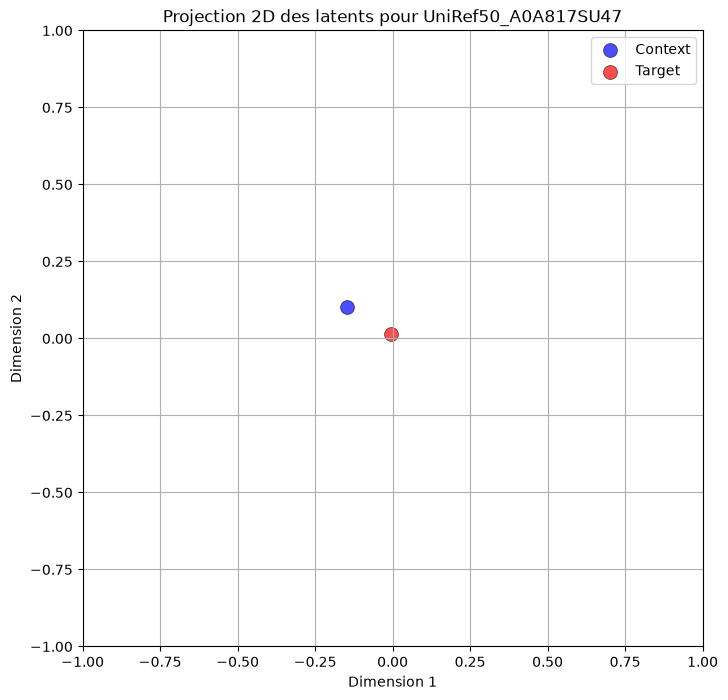

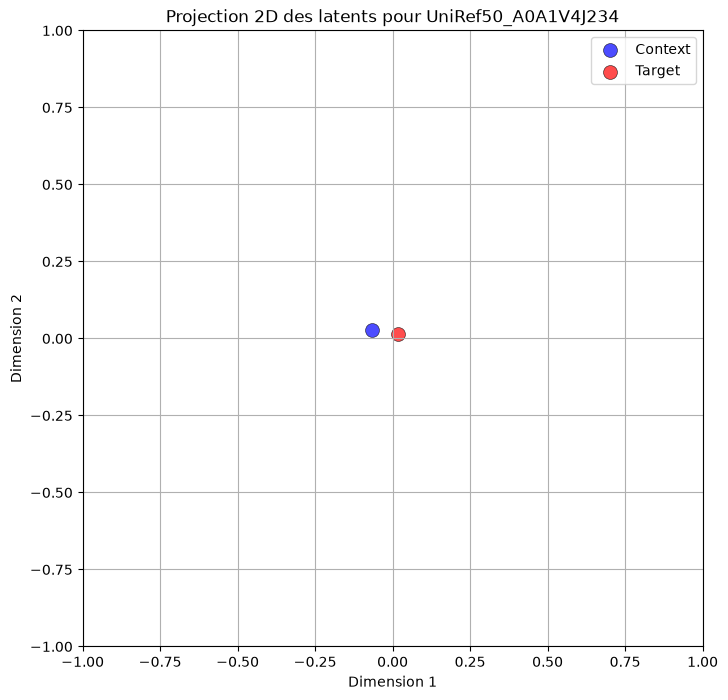

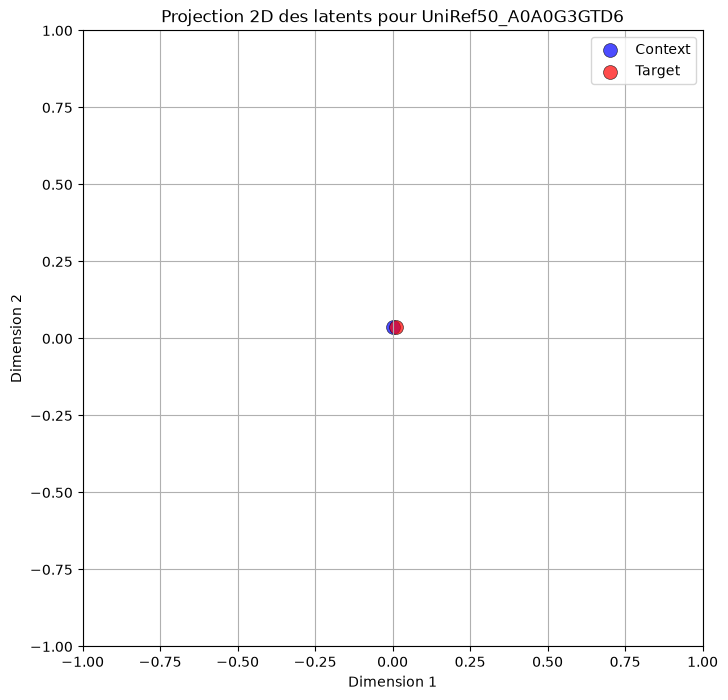

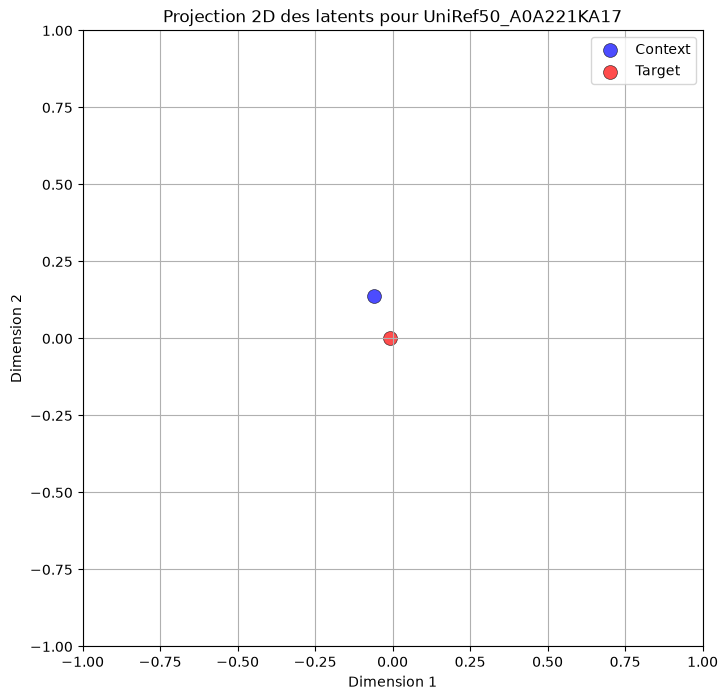

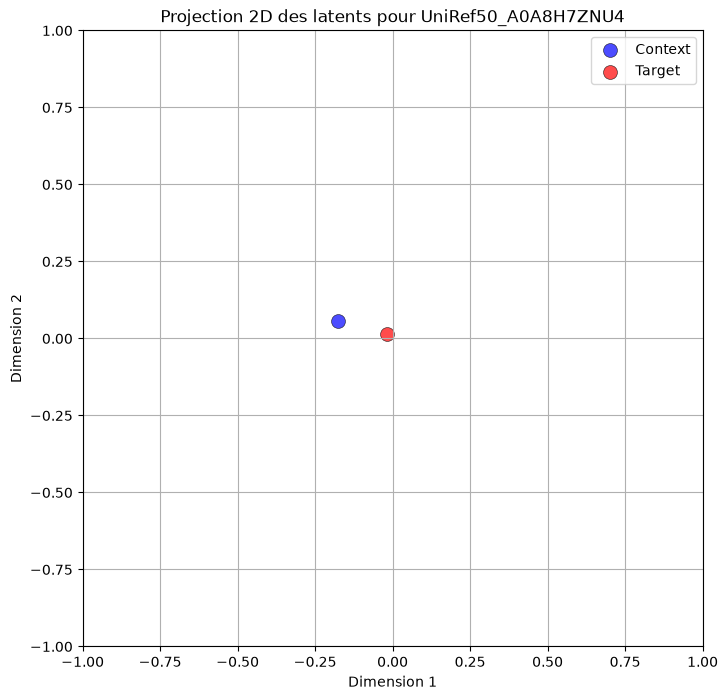

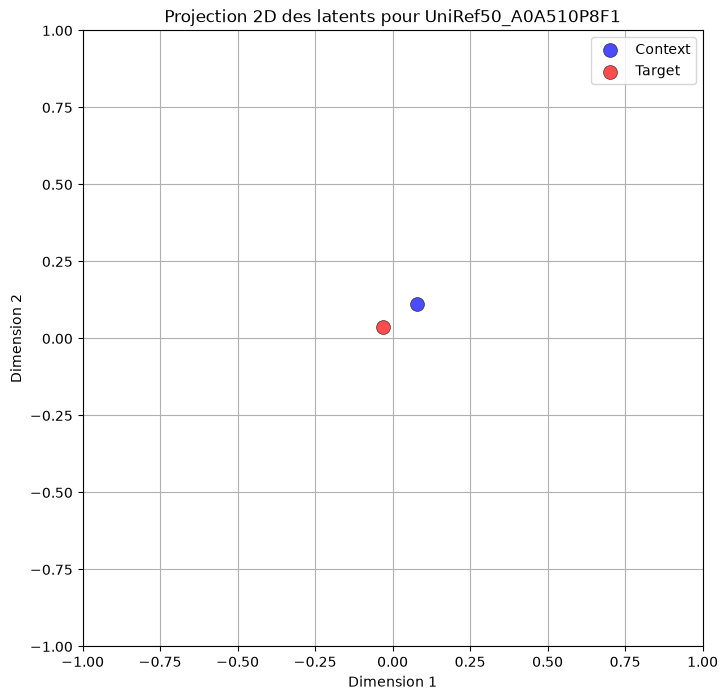

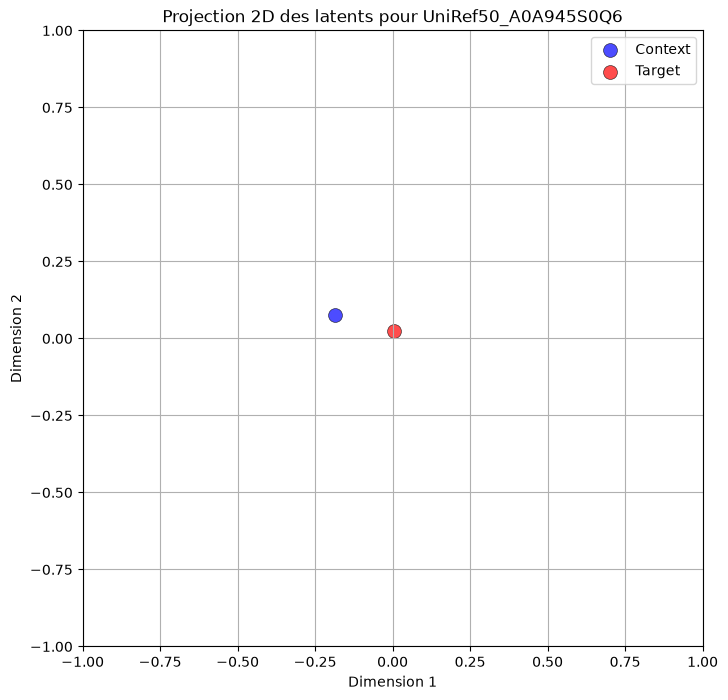

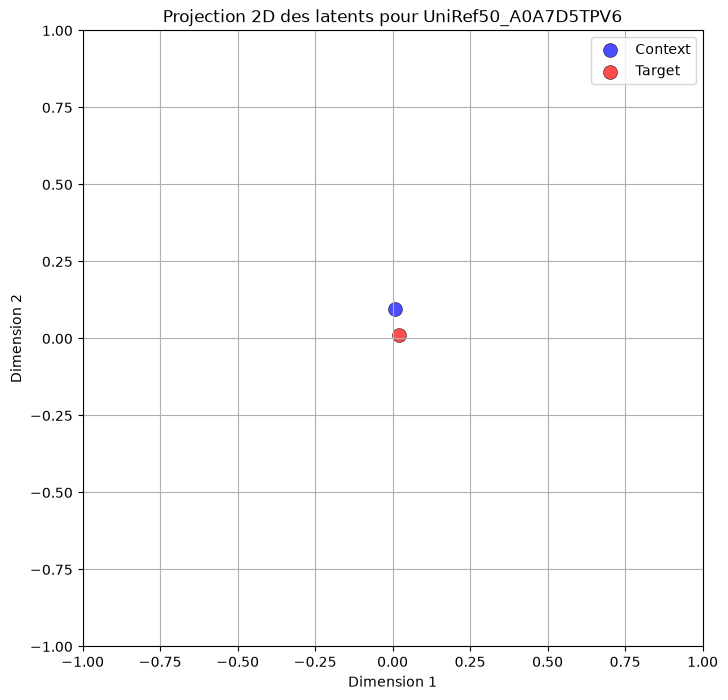

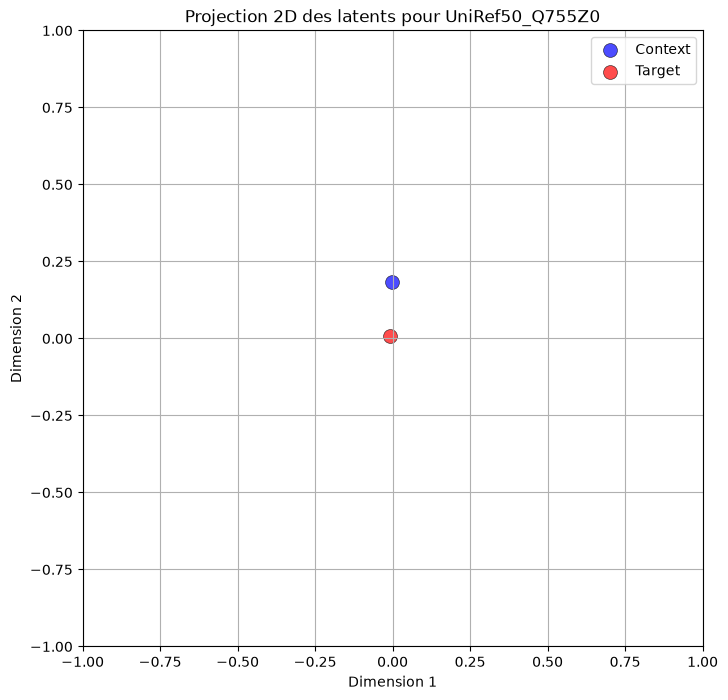

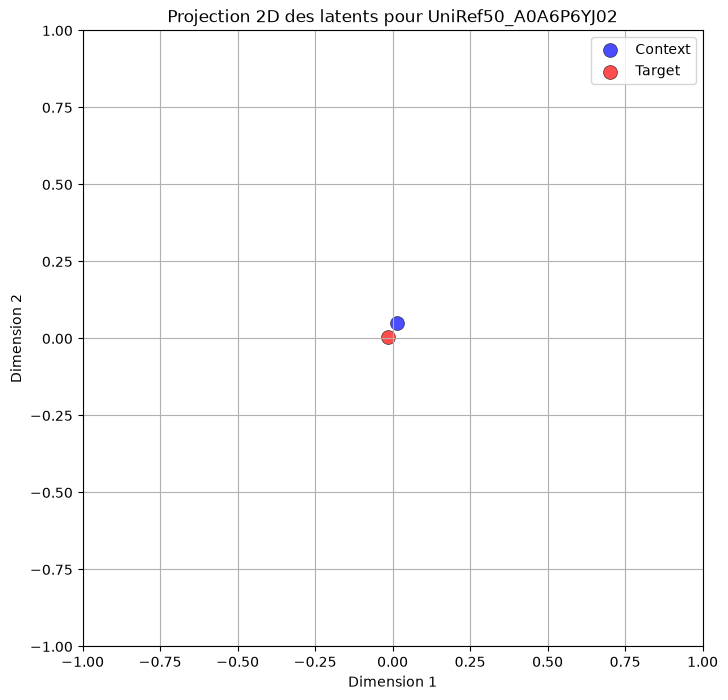

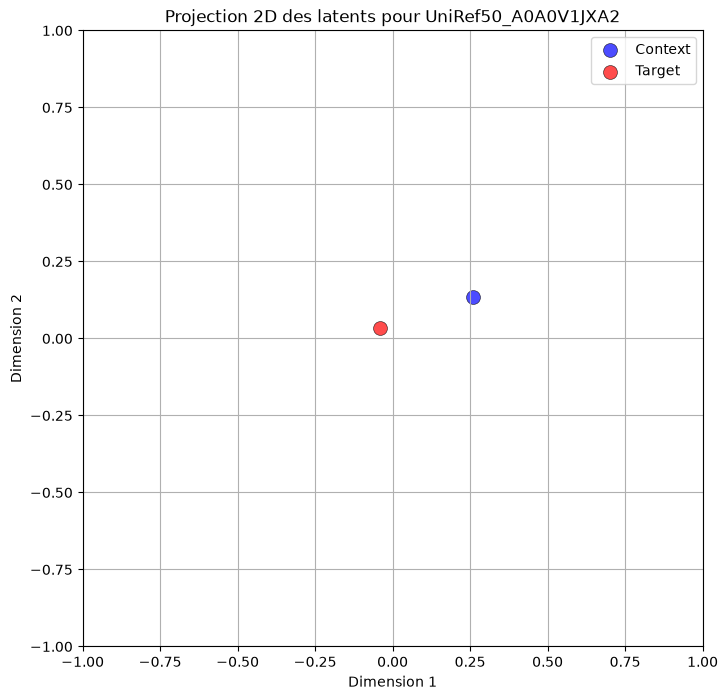

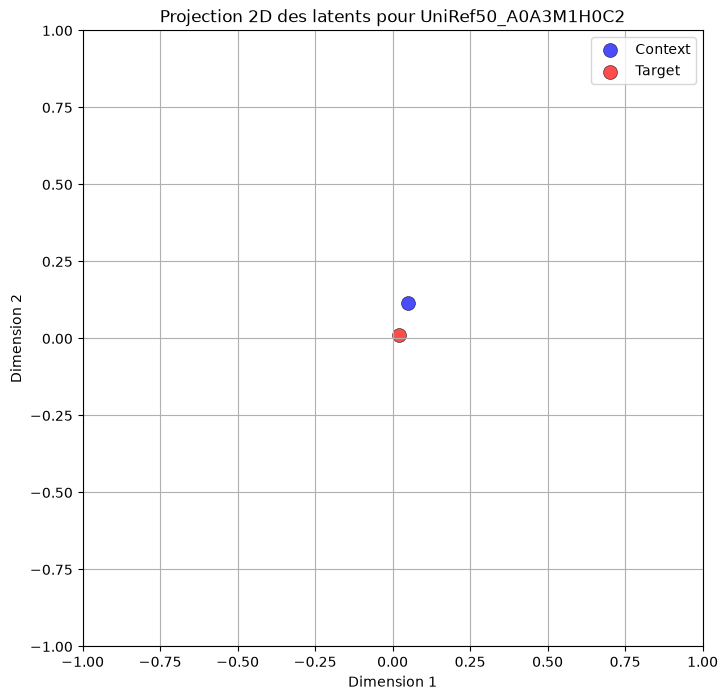

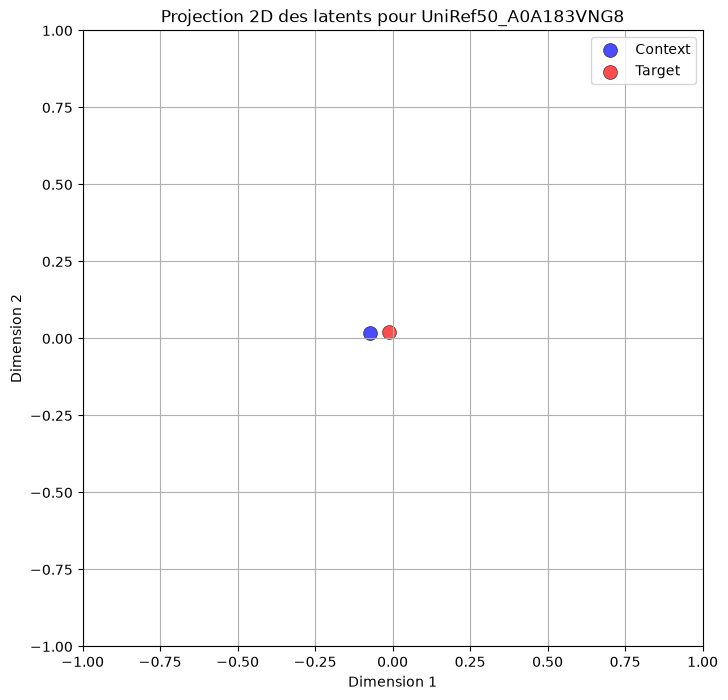

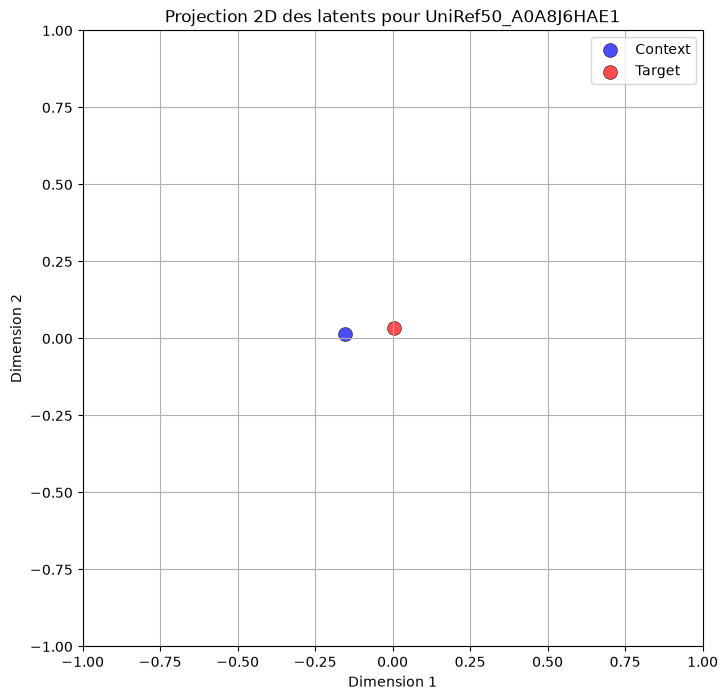

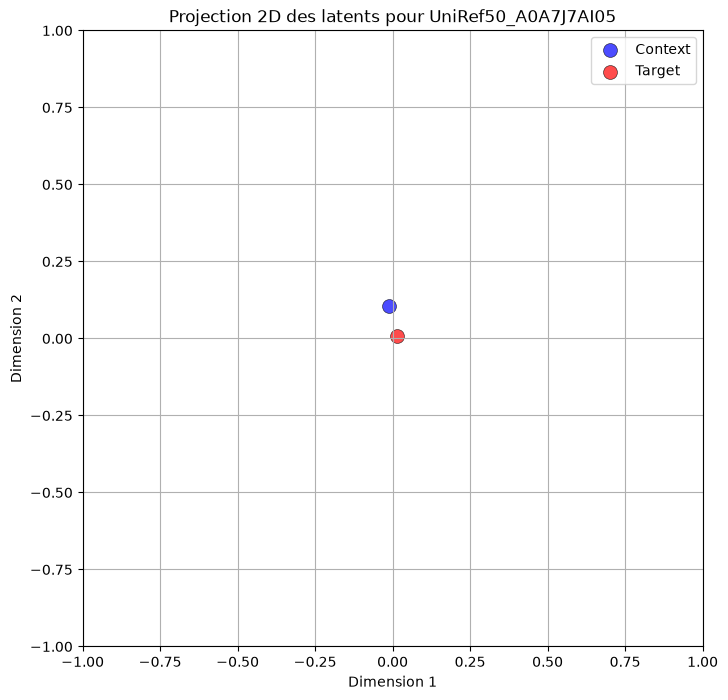

KeyboardInterrupt: 

In [ ]:
# Projection des vecteurs moyens de chaque type d'Acide Aminée en 2D pour visualisation
# Représenter tous les points dans un meme graphe
for i in range(len(list_results)):
    context_latents = list_results[i]["context_latent"].cpu().numpy()
    target_latents = list_results[i]["target_latent"].cpu().numpy()
    
    # Mean pooling pour obtenir un vecteur moyen par protéine
    context_mean = context_latents.mean(axis=0)
    target_mean = target_latents.mean(axis=0)
    
    #modifie la taille du plot aille de 0 à 1.0
    plt.figure(figsize=(8, 8))
    plt.scatter(context_mean[0], context_mean[1], color='blue', label='Context', alpha=0.7, s=100, edgecolors='k', linewidth=0.5)
    plt.scatter(target_mean[0], target_mean[1], color='red', label='Target', alpha=0.7, s=100, edgecolors='k', linewidth=0.5)
    plt.xlim(-1.0, 1.0)
    plt.ylim(-1.0, 1.0)
    plt.title(f"Projection 2D des latents pour {list_results[i]['prot_name']}")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.show()